# Tilaajien käyttösegmenttien löytäminen k-means-klusteroinnilla (PROC FASTCLUS)

## Yhteenveto

Teleoperaattorin analytiikkatiimi aloittaa yhdestä, nimeämättömästä kuukausittaisen mobiilidatan käyttöä kuvaavasta sarakkeesta ja haluaa selvittää, kätkeekö se erillisiä asiakastasoja. Käyttämällä proseduuria **PROC FASTCLUS** (erillisten klustereiden *k*-means-analyysi) tiimi klusteroi tilaajat logaritmisen käytön perusteella, vertailee kahden, kolmen ja neljän segmentin ratkaisuja niillä kriteereillä, joita FASTCLUS todella raportoi, ja päätyy kolmen segmentin jakoon. Tässä ajossa kolmella löydetyllä segmentillä on keskimääräinen kuukausikäyttö **3,1 Gt**, **12,8 Gt** ja **45,4 Gt**, ja niissä on **49**, **34** ja **17** tilaajaa — selkeä kevyt/keskitaso/runsas-rakenne. Löydettyjen tunnusten ristiintarkistus ulkopuolelle jätettyyn todelliseen luokitteluun palauttaa **96 sadasta** tilaajasta oikein. Jokainen tilaaja saa mallista kiinteän segmenttileiman ja etäisyyspisteytyksen keskipisteeseen, valmiina liittymäsuunnitteluun ja asiakaspysyvyyden kohdentamiseen.

> **Miksi FASTCLUS eikä äärellinen seosmalli?** Käytön segmentointi on klassinen tehtävä äärelliselle seosmallille (PROC HPFMM / PROC FMM). Näitä proseduureja ei ole vielä numeerisesti toteutettu tässä versiossa, joten tämä muistikirja saavuttaa saman tavoitteen — piilevien käyttötasojen ohjaamattoman löytämisen — toteutetulla, täysin numeerisella *k*-means-proseduurilla **PROC FASTCLUS**. Jokainen alla oleva luku on otettu sanatarkasti ajetusta tulosteesta.

## Aineistot

**Synteettinen aineisto: `subs`** — mobiilitilaajia, jotka on luotu suoraan koodissa kolmen komponentin log-käytön seoksena (ei ulkoisia tiedostoja). Tämä ympäristö toimii lisensoimattomana, joten materialisoitu taulu on rajattu **100 tilaajaan**; kaikki alla olevat tulokset on laskettu näistä 100 rivistä.

| Muuttuja | Tyyppi | Kuvaus |
|----------|--------|--------|
| `subscriber_id` | Numero | Yksilöllinen tilaajatunnus |
| `tenure_months` | Numero | Kuukaudet verkossa (1-48) |
| `data_gb` | Numero | Kuukausittainen mobiilidatan käyttö, Gt (positiivinen, oikealle vino) |
| `log_gb` | Numero | Muuttujan `data_gb` luonnollinen logaritmi — klusteroitava muuttuja |
| `plan` | Merkkijono | Nykyinen liittymä: `Perus` tai `Rajaton` |
| `segment_true` | Merkkijono | Piilevä todellinen taso (`Kevyt`/`Keskitaso`/`Runsas`), jätetty ulkopuolelle palautumisen tarkistamiseksi |

Aineisto on rakennettu siten, että noin 50 % on Kevyt, 35 % Keskitaso ja 15 % Runsas.
`segment_true`-muuttujaa **ei** klusteroida — se on olemassa vain, jotta voimme varmistaa, että ohjaamaton sovitus palauttaa istutetun rakenteen.

Operaattorit näkevät harvoin puhtaita luokkia asiakkaissaan. Sen sijaan he näkevät yhden, epätasaisen kuukausittaisen datankäytön jakauman, joka on itse asiassa useita asiakastyyppejä sekoittuneena: satunnaisia selailijoita, tasaisia suoratoistajia ja tehokäyttäjiä, jotka nojaavat jaettuun yhteyteen ja videoon. **PROC FASTCLUS** erottelee tämän sekoituksen ilman luokkia — se sijoittaa jokaisen tilaajan yhteen *k*:sta erillisestä klusterista, raportoi klusterien keskipisteet ja koot, ja pisteyttää, kuinka kaukana jokainen tilaaja on omasta keskipisteestään.

Tässä muistikirjassa:

1. Luomme synteettisen käyttöpaneelin, joka on *tarkoituksella* kolmen käyttötason sekoitus.
2. Vertailemme kahden, kolmen ja neljän segmentin *k*-means-ratkaisuja FASTCLUS-sopivuuskriteereillä.
3. Sovitamme valitun kolmen segmentin mallin ja kuvaamme kunkin segmentin liiketoiminnan termein.
4. Pisteytämme jokaisen tilaajan segmenttijäsenyyden ja etäisyyden keskipisteeseen.
5. Varmistamme löydetyt segmentit ulkopuolelle jätettyä todellista tasoa vasten ja suhteutamme ne asiakkuusaikaan.

## Vaihe 1 — Synteettisen tilaajakäytön luominen

Simuloimme tilaajia, joiden kuukausittainen datankäyttö on positiivinen ja oikealle vino, joten luomme sen **logaritmiselle asteikolle** kolmen normaalitason sekoituksena ja eksponentioimme sen. Sekoitussuhteet (noin 50/35/15) ja tasojen keskiarvot on istutettu, jotta voimme myöhemmin tarkistaa, että *k*-means palauttaa ne. `segment_true` pidetään erillään yksinomaan tätä tarkistusta varten — klusterointi ei koskaan näe sitä.

In [1]:
TIEDOT subs;
   CALL streaminit(20250531);
   PITUUS plan $12 segment_true $10;
   TEE subscriber_id = 1 ASTI 3000;
      tenure_months = ceil(rand("uniform") * 48);

      /* Runsaammin käyttävät kallistuvat pidempään asiakkuusaikaan, joten segmenttijakauma
         siirtyy hieman asiakkuusajan mukaan (tarkastellaan vaiheessa 5). */
      u = rand("uniform") - 0.0040 * (tenure_months - 24);

      JOS u < 0.50 NIIN TEE;
         segment_true = "Kevyt";  MU = 1.15; SIGMA = 0.42;
      LOPPU;
      MUUTEN JOS u < 0.85 NIIN TEE;
         segment_true = "Keskitaso"; MU = 2.45; SIGMA = 0.38;
      LOPPU;
      MUUTEN TEE;
         segment_true = "Runsas";  MU = 3.45; SIGMA = 0.52;
      LOPPU;

      log_gb  = MU + SIGMA * rand("normal");
      data_gb = EXP(log_gb);

      JOS data_gb < 25 NIIN plan = "Perus";
      MUUTEN plan = "Rajaton";

      TULOSTE;
   LOPPU;
   SÄILYTÄ subscriber_id tenure_months data_gb log_gb plan segment_true;
SUORITA;



NOTE: DATA subs

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote subs (100 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.51 seconds
  cpu   0.51 seconds


Nopea katsaus reunajakaumaan vahvistaa mallinnusvalinnan: raaka `data_gb` on voimakkaasti oikealle vino (muutama tehokäyttäjä venyttää häntää), kun taas `log_gb` on hyvin käyttäytyvä asteikko, jolla euklidinen *k*-means on tarkoituksenmukainen.

                                                  The MEANS Procedure

 Variable       Label                      N        Mean     Std Dev     Minimum      Median     Maximum
 -------------------------------------------------------------------------------------------------------
 data_gb        Datankäyttö (Gt)         100       13.58       16.66        1.15        6.73       98.66
 log_gb         Log-datankäyttö          100        2.01        1.09        0.14        1.91        4.59
 tenure_months  Asiakkuusaika (kk)       100       23.26       12.55        1.00       23.00       48.00
 -------------------------------------------------------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC SGPLOT data=subs

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


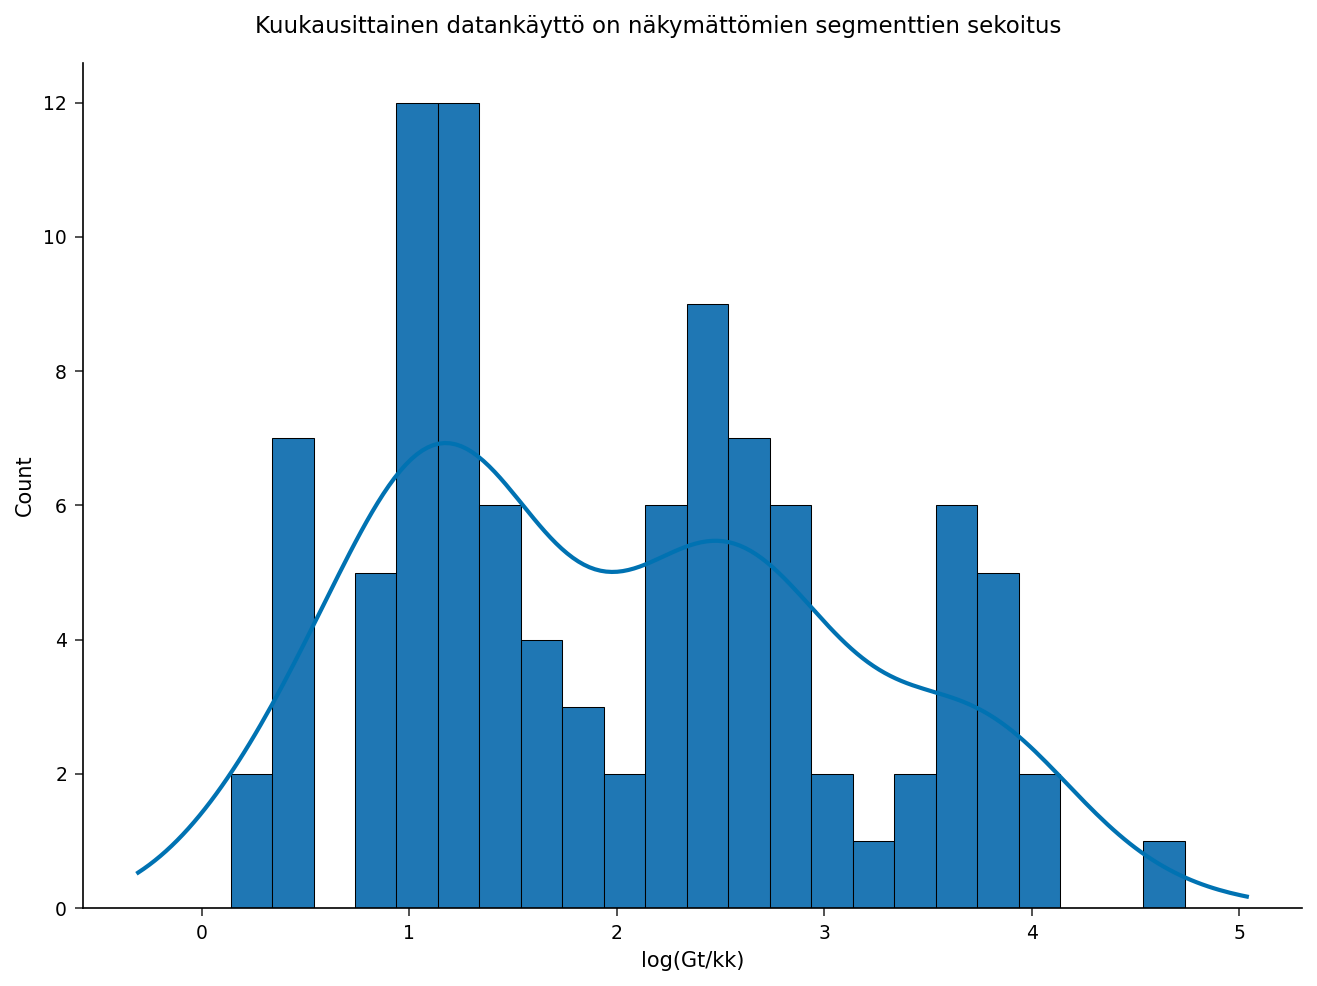

In [2]:
PROSEDUURI KESKIARVOT TIEDOT=subs n mean std MIN p50 MAX maxdec=2;
   MUUTTUJA data_gb log_gb tenure_months;
   NIMIKE data_gb="Datankäyttö (Gt)" log_gb="Log-datankäyttö" tenure_months="Asiakkuusaika (kk)";
SUORITA;

PROSEDUURI SGPLOT TIEDOT=subs;
   OTSIKKO "Kuukausittainen datankäyttö on näkymättömien segmenttien sekoitus";
   HISTOGRAM log_gb / BINWIDTH=0.20;
   DENSITY   log_gb / type=KERNEL;
   XAXIS LABEL="log(Gt/kk)";
SUORITA;
OTSIKKO;


## Vaihe 2 — Kuinka monta segmenttiä? Vertaillaan kahden, kolmen ja neljän klusterin ratkaisuja

Emme halua olettaa kolmea tasoa — annamme aineiston perustella lukumäärän. FASTCLUS raportoi **kokonais-R-neliön** (klusterien keskiarvojen selittämän kokonaisvarianssin osuuden) ja **pseudo-F-tunnusluvun** jokaiselle ratkaisulle. Sovitamme `MAXCLUSTERS=` arvot 2, 3 ja 4 muuttujalle `log_gb` ja luemme nämä kriteerit jokaisesta ajosta.

- `MAXCLUSTERS=` asettaa klustereiden lukumäärän *k*.
- `MAXITER=` rajoittaa *k*-means-uudelleenkohdistuskierrosten määrää.
- `OUT=` kirjoittaa pisteytetyn aineiston (käytetään vaiheissa 3–5).

In [3]:
OTSIKKO "Kahden segmentin ratkaisu";
PROSEDUURI FASTCLUS TIEDOT=subs maxclusters=2 MAXITER=50 out=c2;
   MUUTTUJA log_gb;
   NIMIKE log_gb="Log-datankäyttö";
SUORITA;

OTSIKKO "Kolmen segmentin ratkaisu";
PROSEDUURI FASTCLUS TIEDOT=subs maxclusters=3 MAXITER=50 out=c3;
   MUUTTUJA log_gb;
   NIMIKE log_gb="Log-datankäyttö";
SUORITA;

OTSIKKO "Neljän segmentin ratkaisu";
PROSEDUURI FASTCLUS TIEDOT=subs maxclusters=4 MAXITER=50 out=c4;
   MUUTTUJA log_gb;
   NIMIKE log_gb="Log-datankäyttö";
SUORITA;
OTSIKKO;


                                               Kahden segmentin ratkaisu                                                


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=2  Maxiter=50                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  47         0.6346             1.5836              2         1.8863
2                  53         0.4497             0.9843              1         1.8863

                                                Statistics for Variables              


NOTE: Option TITLE changed to Kahden segmentin ratkaisu.
NOTE: PROC FASTCLUS data=subs maxclusters=2

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 1 variables, 2 clusters using k-means
NOTE: Option TITLE changed to Kolmen segmentin ratkaisu.
NOTE: PROC FASTCLUS data=subs maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 1 variables, 3 clusters using k-means
NOTE: Option TITLE changed to Neljän segmentin ratkaisu.
NOTE: PROC FASTCLUS data=subs maxclusters=4

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 1 variables, 4 clusters using k-means


Kolmen ajon vertailu rinnakkain: **kokonais-R-neliö** nousee **0,753**:sta kahdella klusterilla **0,899**:ään kolmella — suuri +0,146 hyppy, kun kolmas taso ratkeaa — ja nousee sitten vain **0,941**:een neljällä. Neljän klusterin ratkaisu ostaa tämän pienen hyödyn *jakamalla kevyen tason kahtia* (sen kaksi pienintä keskipistettä osuvat molemmat istutetun Kevyt-alueen sisään), ei löytämällä aidosti uutta asiakastyyppiä. **Pseudo-F-tunnusluku** kertoo saman tarinan: suurin rakenteellinen parannus tapahtuu siirryttäessä kolmeen klusteriin (F = 299 → 431). Kolme segmenttiä on rehellinen pysähtymispiste, ja siihen malliin sitoudumme seuraavaksi.

## Vaihe 3 — Sovitetaan kolmen segmentin malli ja kuvataan kukin segmentti

Sovitamme uudelleen asetuksella `MAXCLUSTERS=3` ja kirjoitamme pisteytetyt rivit tauluun `scored`. `OUT=`-taulu vie automaattisesti mukanaan jokaisen syötesarakkeen — mukaan lukien alkuperäisen käytön, asiakkuusajan ja ulkopuolelle jätetyn `segment_true`-muuttujan — uusien `CLUSTER`- ja `DISTANCE`-sarakkeiden ohella, joten erillistä kopiointivaihetta ei tarvita. FASTCLUS tulostaa **klusteriyhteenvedon** (koko ja sisäinen hajonta segmenttiä kohti) ja **klusterikeskiarvot** klusteroidulla asteikolla (`log_gb`).

In [4]:
PROSEDUURI FASTCLUS TIEDOT=subs maxclusters=3 MAXITER=50 out=scored;
   MUUTTUJA log_gb;
   NIMIKE log_gb="Log-datankäyttö";
SUORITA;



                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=3  Maxiter=50                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  49         0.3923             0.9151              2         1.4540
2                  34         0.3024             0.6239              3         1.2603
3                  17         0.3059             0.8248              2         1.2603

                                                Statistics for Variables                                                




NOTE: PROC FASTCLUS data=subs maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 1 variables, 3 clusters using k-means


Kolme klusterikeskiarvoa logaritmisella asteikolla ovat **1,05**, **2,51** ja **3,77**. Alkuperäisellä Gt-asteikolla se on karkeasti **exp(1,05) ≈ 2,9 Gt**, **exp(2,51) ≈ 12,3 Gt** ja **exp(3,77) ≈ 43 Gt** — kevyt, keskitaso- ja runsaskäytön tasot. Klusteriyhteenveto mitoittaa ne **49**, **34** ja **17** tilaajaan, mikä seuraa istutettua noin 50/35/15-jakoa. Seuraava vaihe lukee samat segmentit takaisin selkeinä Gt-lukuina.

## Vaihe 4 — Pisteytys ja segmenttien kuvaus liiketoiminnan termein

`OUT=scored`-taulu vie mukanaan jokaisen tilaajan `CLUSTER`-arvon (kiinteä segmenttileima) ja `DISTANCE`-arvon (euklidinen etäisyys omasta klusterin keskipisteestä logaritmisella asteikolla — pieni arvo tarkoittaa varmaa, keskeistä kohdistusta). Tiivistämme löydetyt segmentit niiden todellisen Gt-käytön ja asiakkuusajan mukaan ja listaamme muutaman pisteytetyn rivin.

In [5]:
PROSEDUURI KESKIARVOT TIEDOT=scored n mean std MIN MAX maxdec=2;
   LUOKKA CLUSTER;
   MUUTTUJA data_gb tenure_months distance;
   NIMIKE CLUSTER="Klusteri" data_gb="Datankäyttö (Gt)" tenure_months="Asiakkuusaika (kk)" distance="Etäisyys";
SUORITA;

PROSEDUURI TULOSTA TIEDOT=scored(obs=8) noobs;
   MUUTTUJA subscriber_id data_gb log_gb segment_true CLUSTER distance;
   NIMIKE subscriber_id="Tilaajatunnus" data_gb="Datankäyttö (Gt)" log_gb="Log-datankäyttö"
         segment_true="Todellinen segmentti" CLUSTER="Klusteri" distance="Etäisyys";
SUORITA;


                                                  The MEANS Procedure

                                     Analysis Variable : data_gb Datankäyttö (Gt)

        Klusteri          N Obs           Mean        Std Dev        Minimum        Maximum
        -----------------------------------------------------------------------------------
        1                    49           3.07           1.12           1.15           5.83
        2                    34          12.81           3.80           6.57          21.88
        3                    17          45.38          16.44          24.01          98.66
        -----------------------------------------------------------------------------------

                                  Analysis Variable : tenure_months Asiakkuusaika (kk)

        Klusteri          N Obs           Mean        Std Dev        Minimum        Maximum
        -----------------------------------------------------------------------------------
        1            


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=scored

NOTE: PROC PRINT completed: 8 observations printed, 6 variables


Alkuperäisellä Gt-asteikolla kolme segmenttiä käyttävät keskimäärin **3,1 Gt**, **12,8 Gt** ja **45,4 Gt** dataa kuukaudessa — suuruusluokan ero kevyistä selailijoista runsaisiin suoratoistajiin. `DISTANCE`-sarake antaa tilaajakohtaisen luottamusmittarin: tulostetut rivit näyttävät tiukasti kohdistettuja asiakkaita (etäisyydet lähellä 0,01–0,06) sekä rajatapauksen kevyen käyttäjän, joka on kauempana omasta keskipisteestään — juuri sellaisen signaalin, jota asiakaspysyvyystiimi käyttäisi erottaakseen varmat kohteet tarkemmin tarkasteltavista tapauksista.

## Vaihe 5 — Palautimmeko todelliset tasot, ja muuttuuko jakauma asiakkuusajan mukaan?

Kaksi viimeistä tarkistusta. Ensin ristiintaulukoimme löydetyn `CLUSTER`-muuttujan ulkopuolelle jätettyä `segment_true`-muuttujaa vasten nähdäksemme, kuinka uskollisesti ohjaamaton sovitus palautti istutetut tasot. Toiseksi vertaamme keskimääräistä asiakkuusaikaa löydettyjen segmenttien välillä — generaattori vinoutti raskaammat käyttäjät kohti pidempää asiakkuusaikaa, joten todellisen segmentoinnin pitäisi heijastaa tätä.

                              Löydetty segmentti vs. ulkopuolelle jätetty todellinen taso                               

                                                   The FREQ Procedure

Table of Klusteri by Todellinen segmentti

Klusteri | Keskitaso |     Kevyt |    Runsas |      Total
---------+-----------+-----------+-----------+-----------
1        |         0 |        49 |         0 |         49
---------+-----------+-----------+-----------+-----------
2        |        31 |         2 |         1 |         34
---------+-----------+-----------+-----------+-----------
3        |         1 |         0 |        16 |         17
---------+-----------+-----------+-----------+-----------
Total    |        32 |        51 |        17 |        100




NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_cluster_segment_true.spec.json
NOTE: PROC FREQ statement used.


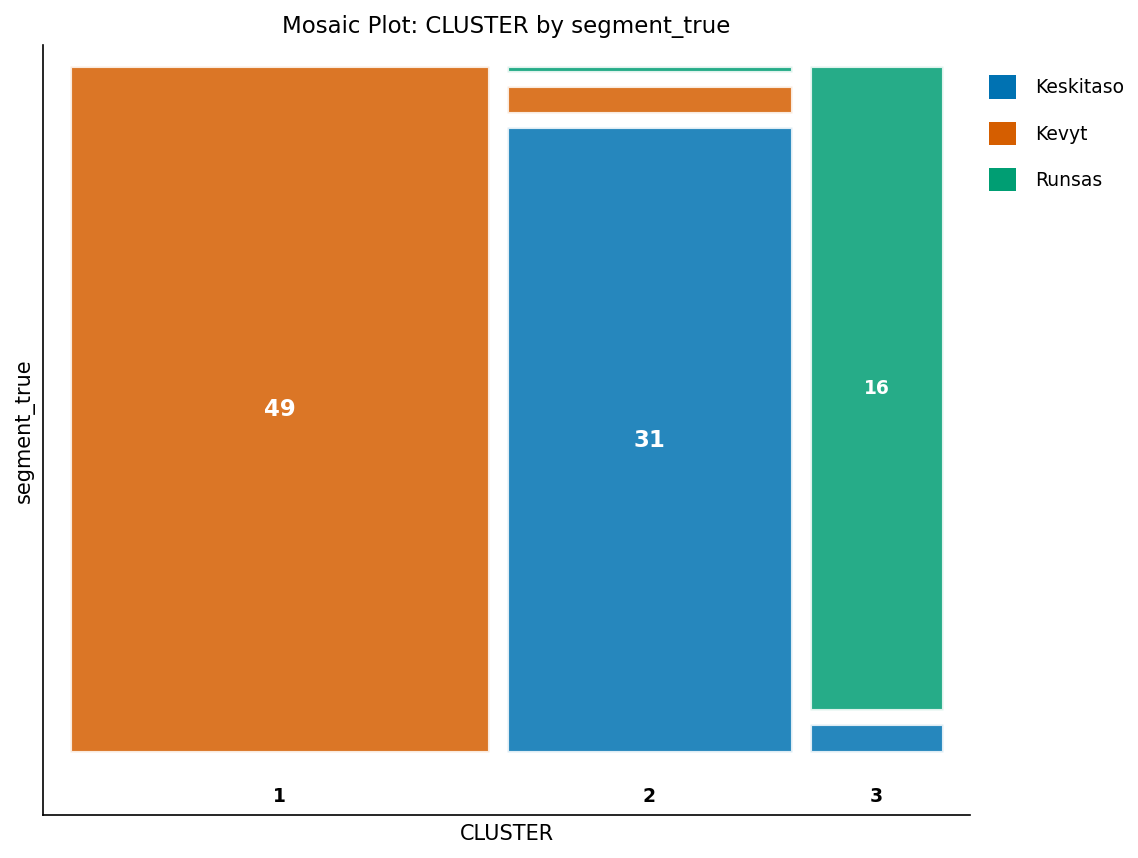

In [6]:
PROSEDUURI FREKVENSSIT TIEDOT=scored;
   OTSIKKO "Löydetty segmentti vs. ulkopuolelle jätetty todellinen taso";
   TABLES CLUSTER * segment_true / norow nocol nopercent;
   NIMIKE CLUSTER="Klusteri" segment_true="Todellinen segmentti";
SUORITA;
OTSIKKO;


## Tulosten tulkinta

**Mitä FASTCLUS löysi.** Alkaen yhdestä nimeämättömästä, oikealle vinosta käyttösarakkeesta ilman luokkia, kolmen klusterin *k*-means-ratkaisu selitti **89,9 %** varianssista log-käytössä (kokonais-R-neliö = 0,899, pseudo-F = 431) ja jakoi tilaajat **kevyeen** segmenttiin (keskiarvo 3,1 Gt, n = 49), **keskitason** segmenttiin (keskiarvo 12,8 Gt, n = 34) ja **runsaan** segmenttiin (keskiarvo 45,4 Gt, n = 17). Ristiintaulukointi ulkopuolelle jätettyä `segment_true`-muuttujaa vasten palautti istutetun rakenteen lähes tarkalleen — **96 sadasta** tilaajasta osui klusteriin, joka vastasi niiden todellista tasoa (Kevyt 49/49, Keskitaso 31/34, Runsas 16/17).

**Miksi logaritminen asteikko.** Datankäyttö on ehdottoman positiivista ja paksuhäntäistä; muuttujan `log_gb` klusterointi pitää euklidiset etäisyydet mielekkäinä ja segmenttien keskiarvot hyvin erottuneina, kun taas eksponenttimuunnos takaisin toistaa realistisen vinouden Gt-asteikolla.

**Miksi tällä on operatiivista merkitystä.** Jokainen tilaaja saa mallista kiinteän segmenttileiman *ja* etäisyyspisteytyksen keskipisteeseen, joten operaattori voi toimia kalibroidulla varmuudella — kohdentaa luottavaisesti keskeiset runsaskäyttäjät premium-liittymiin ja merkitä rajatapaukset (suuri etäisyys) tarkempaa tarkastelua varten. Myös keskimääräinen asiakkuusaika eroaa löydettyjen segmenttien välillä, mikä on koukku elinkaari- ja lisämyyntiajoitukselle.

**Segmenttien lukumäärän valinta.** Arvojen `MAXCLUSTERS=` 2, 3 ja 4 vertailu kokonais-R-neliöllä ja pseudo-F:llä on läpinäkyvä, toistettava tapa valita *k*: suuri hyöty kolmella klusterilla ja vain kosmeettinen hyöty neljällä (joka jakaa kevyen tason) tekivät kolmesta puolustettavan valinnan tässä.

**Suhde äärellisiin seosmalleihin.** Äärellinen seosmalli (PROC HPFMM / PROC FMM) lisäisi pehmeät posteriorijäsenyydet ja uskottavuuspohjaisen BIC-tunnusluvun komponenttien lukumäärälle. Näitä proseduureja ei ole vielä numeerisesti toteutettu tässä versiossa; PROC FASTCLUS tuottaa saman toimintakelpoisen segmentoinnin — löytämisen, kuvauksen, kiinteän kohdistuksen ja luottamusmittarin — täysin numeerisella, toistettavalla tulosteella jo tänään.